## $\texttt{Random Number Generation}$

#### 线性同余随机数生成器
  $$X_{n+1} = (aX_n + c) \mod m \qquad \text{例如：} 5 \bmod 3 = 2$$

其中：

- $X_n$ 是当前的随机数
- $a$ 是一个乘法因子
- $c$ 是一个增量
- $m$ 是模数
- $\bmod$ 表示取模运算

- *下面几个cell分别是在做“控制生成的随机数的范围”*

In [5]:
class LinearCongruentialGenerator:
    def __init__(self, seed, a, c, m):
        self.x = seed  # 初始化种子
        self.a = a  # 乘法因子
        self.c = c  # 增量因子
        self.m = m  # 模数

    def next(self):
        # 使用线性同余公式生成下一个随机数
        self.x = (self.a * self.x + self.c) % self.m
        return self.x

    def generate(self, num_samples):
        # 生成 num_samples 个随机数
        return [self.next() for _ in range(num_samples)]

# 示例：使用常见的参数来测试 LCG
seed = 12345  # 种子值
a = 1664525  # 乘法因子（常用的一个值）
c = 1013904223  # 增量因子（常用的一个值）
m = 2**32  # 模数，通常选择 2 的幂

lcg = LinearCongruentialGenerator(seed, a, c, m)
random_numbers = lcg.generate(10)  # 生成 10 个随机数


print(random_numbers)


[87628868, 71072467, 2332836374, 2726892157, 3908547000, 483019191, 2129828778, 2355140353, 2560230508, 3364893915]


In [6]:
# 生成 10 个 [0, 1) 之间的随机数;可以通过将生成的随机数除以模数 m 来实现标准化。 
class LinearCongruentialGenerator:
    def __init__(self, seed, a, c, m):
        self.x = seed  # 初始化种子
        self.a = a  # 乘法因子
        self.c = c  # 增量因子
        self.m = m  # 模数

    def next(self):
        # 使用线性同余公式生成下一个随机数
        self.x = (self.a * self.x + self.c) % self.m
        # 标准化到 [0, 1) 范围
        return self.x / self.m

    def generate(self, num_samples):
        # 生成 num_samples 个随机数
        return [self.next() for _ in range(num_samples)]

# 示例：使用常见的参数来测试 LCG
seed = 12345  # 种子值
a = 1664525  # 乘法因子（常用的一个值）
c = 1013904223  # 增量因子（常用的一个值）
m = 2**32  # 模数，通常选择 2 的幂

lcg = LinearCongruentialGenerator(seed, a, c, m)
random_numbers = lcg.generate(10)  # 生成 10 个 [0, 1) 之间的随机数


print(random_numbers)


[0.02040268573909998, 0.01654784823767841, 0.5431557944975793, 0.6349040560889989, 0.9100295137614012, 0.11246166913770139, 0.4958894052542746, 0.5483488442841917, 0.5961001170799136, 0.7834504160564393]


In [4]:
# 生成 10 个 [-1, 2) 之间的随机数; 线性映射
class LinearCongruentialGenerator:
    def __init__(self, seed, a, c, m):
        self.x = seed  # 初始化种子
        self.a = a  # 乘法因子
        self.c = c  # 增量因子
        self.m = m  # 模数

    def next(self):
        # 使用线性同余公式生成下一个随机数
        self.x = (self.a * self.x + self.c) % self.m
        # 标准化到 [0, 1) 范围
        normalized_value = self.x / self.m
        # 将 [0, 1) 映射到 [-1, 2)
        return 3 * normalized_value - 1

    def generate(self, num_samples):
        # 生成 num_samples 个 [-1, 2) 之间的随机数
        return [self.next() for _ in range(num_samples)]

# 示例：使用常见的参数来测试 LCG
seed = 12345  # 种子值
a = 1664525  # 乘法因子（常用的一个值）
c = 1013904223  # 增量因子（常用的一个值）
m = 2**32  # 模数，通常选择 2 的幂

lcg = LinearCongruentialGenerator(seed, a, c, m)
random_numbers = lcg.generate(10)  # 生成 10 个 [-1, 2) 之间的随机数

print(random_numbers)

[-0.9387919427827001, -0.9503564552869648, 0.629467383492738, 0.9047121682669967, 1.7300885412842035, -0.6626149925868958, 0.4876682157628238, 0.6450465328525752, 0.7883003512397408, 1.3503512481693178]


#### 通过PLOT验证其存在周期性

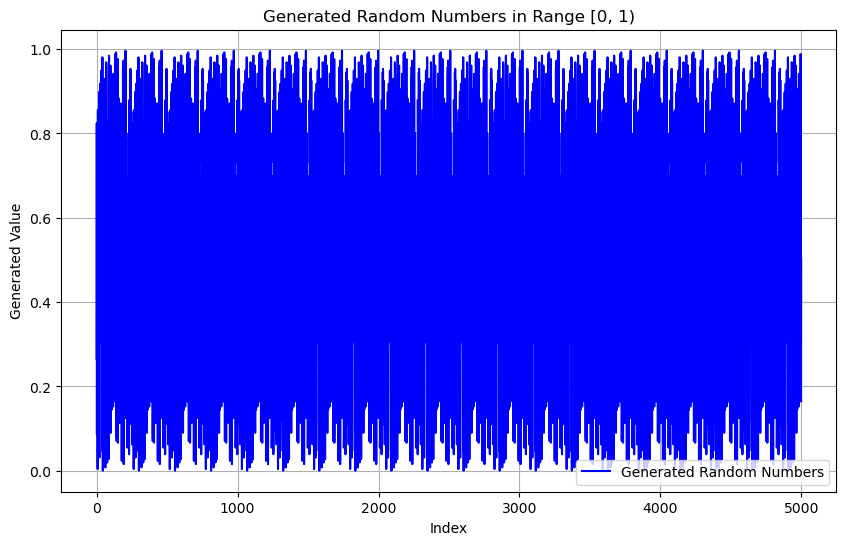

In [68]:
import matplotlib.pyplot as plt

class LinearCongruentialGenerator:
    def __init__(self, seed, a, c, m):
        self.x = seed  # 初始化种子
        self.a = a  # 乘法因子
        self.c = c  # 增量因子
        self.m = m  # 模数

    def next(self):
        # 使用线性同余公式生成下一个随机数
        self.x = (self.a * self.x + self.c) % self.m
        # 标准化到 [0, 1) 范围
        return self.x / self.m

    def generate(self, num_samples):
        # 生成 num_samples 个随机数
        return [self.next() for _ in range(num_samples)]

# LCG 参数设置（可以调整这些值进行实验）
seed = 12345  # 种子值
a = 1664525  # 乘法因子（常用的一个值）
c = 1013904223  # 增量因子（常用的一个值）
m = 2**8  # 模数，通常选择 2 的幂 ； 代表周期

# 创建 LCG 实例并生成随机数
lcg = LinearCongruentialGenerator(seed, a, c, m)
num_samples = 5000  # 生成 50000 个 [0, 1) 之间的随机数
random_numbers = lcg.generate(num_samples)

# 绘制展示生成的随机数
plt.figure(figsize=(10, 6))
plt.plot(random_numbers, label="Generated Random Numbers", color='blue')
plt.xlabel('Index')
plt.ylabel('Generated Value')
plt.title('Generated Random Numbers in Range [0, 1)')
plt.grid(True)
plt.legend()
plt.show()




In [90]:
# 检查周期性：我们将检查生成的数值是否存在重复
for i in range(len(random_numbers)):
    num = random_numbers[i]
    if num in random_numbers[:i]:
        print(f"周期开始于第 {i} 个随机数（值为 {num}）")
        break

周期开始于第 256 个随机数（值为 0.265625）


#### 真随机数

In [26]:
import os

def true_random(min_val=-1, max_val=1):
    # 从 /dev/random 获取 4 字节 (32 位)
    rand_bytes = os.urandom(4)
    print("随机字节数据（4字节）：", rand_bytes)
    
    # 将字节数据转换为一个无符号整数
    rand_int = int.from_bytes(rand_bytes, byteorder='big')
    print("转换后的无符号整数：", rand_int)
    
    # 将值映射到 [-1, 1) 区间
    mapped_value = min_val + (rand_int / (2**32)) * (max_val - min_val)
    print(f"映射到 [{min_val}, {max_val}) 区间后的值：", mapped_value)
    
    return mapped_value

# 示例：生成一个 [-1, 1] 范围的真随机数
print("最终生成的真随机数：", true_random())


随机字节数据（4字节）： b'\x18\xd0\xdc*'
转换后的无符号整数： 416341034
映射到 [-1, 1) 区间后的值： -0.8061260981485248
最终生成的真随机数： -0.8061260981485248


In [25]:
#判断这个是否有周期
import os

def true_random(min_val=-1, max_val=1):
    rand_bytes = os.urandom(4)
    rand_int = int.from_bytes(rand_bytes, byteorder='big')
    mapped_value = min_val + (rand_int / (2**32)) * (max_val - min_val)
    return mapped_value

def check_for_period(num_randoms=1000):
    random_numbers = []  # 用列表存储生成的随机数
    
    for i in range(num_randoms):
        random_value = true_random()
        random_numbers.append(random_value)
        
        # 检查当前随机数是否已经在之前的随机数中出现过
        if random_value in random_numbers[:i]:
            print(f"周期开始于第 {i} 个随机数，值为 {random_value}")

    else:
        print("没有发现周期")

# 生成并检查是否有周期
check_for_period(1000)

没有发现周期


#### 另一个方法是使用 Python 的 secrets 模块，它提供了一个强大的伪随机数生成器，适用于密码学级别的随机数。

没有发现周期


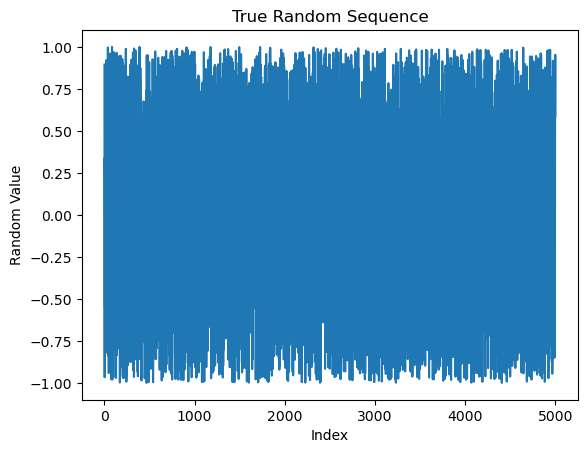

In [24]:
import secrets
import matplotlib.pyplot as plt

def true_random_secrets(min_val=-1, max_val=1):
    # 生成一个 32 位无符号整数
    rand_int = secrets.randbits(32)
    
    # 将值映射到 [-1, 1) 区间
    return min_val + (rand_int / (2**32)) * (max_val - min_val)

def check_for_period(num_randoms=10000):
    random_numbers = []  # 用列表存储生成的随机数
    
    for i in range(num_randoms):
        random_value = true_random_secrets()
        random_numbers.append(random_value)
        
        # 检查当前随机数是否已经在之前的随机数中出现过
        if random_value in random_numbers[:i]:
            print(f"周期开始于第 {i} 个随机数，值为 {random_value}")
            break
    else:
        print("没有发现周期")

    return random_numbers

# 测试周期性并生成随机数序列
random_numbers = check_for_period(5000)

# 观察随机数分布
plt.plot(random_numbers)
plt.title("True Random Sequence")
plt.xlabel("Index")
plt.ylabel("Random Value")
plt.show()


#### 方差，平均值 （正态，均匀，指数分布）

In [33]:
import numpy as np

# 示例 1：正态分布
mu = 0        # 均值
sigma = 1     # 标准差
num_samples = 100000  # 样本数

# 生成正态分布的随机变量
random_normal = np.random.normal(mu, sigma, num_samples)

# 计算样本的平均值和方差
mean_normal = np.mean(random_normal)
variance_normal = np.var(random_normal)

# 理论值
theoretical_mean_normal = mu
theoretical_variance_normal = sigma**2

print(f"正态分布 - 样本期望值: {mean_normal}, 理论期望值: {theoretical_mean_normal}")
print(f"正态分布 - 样本方差: {variance_normal}, 理论方差: {theoretical_variance_normal}")
print()

# 示例 2：均匀分布
low = 0       # 最小值
high = 10     # 最大值

# 生成均匀分布的随机变量
random_uniform = np.random.uniform(low, high, num_samples)

# 计算样本的平均值和方差
mean_uniform = np.mean(random_uniform)
variance_uniform = np.var(random_uniform)

# 理论值
theoretical_mean_uniform = (low + high) / 2
theoretical_variance_uniform = ((high - low) ** 2) / 12

print(f"均匀分布 - 样本期望值: {mean_uniform}, 理论期望值: {theoretical_mean_uniform}")
print(f"均匀分布 - 样本方差: {variance_uniform}, 理论方差: {theoretical_variance_uniform}")
print()

# 示例 3：指数分布
scale = 1     # 率参数

# 生成指数分布的随机变量
random_expon = np.random.exponential(scale, num_samples)

# 计算样本的平均值和方差
mean_expon = np.mean(random_expon)
variance_expon = np.var(random_expon)

# 理论值
theoretical_mean_expon = scale
theoretical_variance_expon = scale**2

print(f"指数分布 - 样本期望值: {mean_expon}, 理论期望值: {theoretical_mean_expon}")
print(f"指数分布 - 样本方差: {variance_expon}, 理论方差: {theoretical_variance_expon}")

正态分布 - 样本期望值: 0.004704606385872272, 理论期望值: 0
正态分布 - 样本方差: 0.9995498087089558, 理论方差: 1

均匀分布 - 样本期望值: 4.992338058752314, 理论期望值: 5.0
均匀分布 - 样本方差: 8.313547791821616, 理论方差: 8.333333333333334

指数分布 - 样本期望值: 1.0068016400584947, 理论期望值: 1
指数分布 - 样本方差: 0.9974256149393251, 理论方差: 1


## $\texttt{Sampling Methods}$

### 逆变换采样（Inverse Transform Sampling）

逆变换采样是一种通过均匀分布的随机数生成目标分布样本的常见方法。其基本思想是利用目标分布的累积分布函数（CDF）和其逆函数来从目标分布中采样。当目标分布的CDF有明确的解析表达式时，可以使用该方法。
#### 逆变换采样的基本步骤：

1. **生成均匀分布的随机数**：
   从 $[0, 1]$ 区间生成一个均匀分布的随机数 $u \in [0, 1]$。
   
2. **应用逆CDF**：
   使用目标分布的累积分布函数 $F(x)$ 的逆函数 $F^{-1}(u)$，根据生成的均匀随机数 $u$ 计算目标分布的样本 $x$。
   
#### 以指数分布为例：

假设目标分布是指数分布，其概率密度函数（PDF）为：

$$
f(x) = \lambda e^{-\lambda x}, \quad x \geq 0
$$

其中，$\lambda$ 是指数分布的速率参数。

指数分布的累积分布函数（CDF）为：

$$
F(x) = 1 - e^{-\lambda x}, \quad x \geq 0
$$

为了进行逆变换采样，我们需要计算累积分布函数 $F(x)$ 的逆函数：

$$
F^{-1}(u) = -\frac{1}{\lambda} \ln(1 - u), \quad u \in [0, 1]
$$

#### 逆变换采样的步骤：

- 生成一个均匀分布的随机数 $u \in [0, 1]$。
- 计算目标分布的样本：$ x = F^{-1}(u) = -\frac{1}{\lambda} \ln(1 - u)$。
  
该方法可以应用于任何具有可逆累积分布函数的分布。对于其他的分布，只需用对应的逆CDF公式代替即可。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 指数分布的累积分布函数（CDF）的逆函数
def inverse_transform_sampling_exponential(lambda_param, n_samples):
    # 生成均匀分布的随机数
    u = np.random.rand(n_samples)
    # 应用逆CDF公式生成样本
    samples = -np.log(1 - u) / lambda_param
    return samples

# 参数
lambda_param = 1.0  # 指数分布的lambda参数
n_samples = 10000   # 生成的样本数

# 生成样本
samples = inverse_transform_sampling_exponential(lambda_param, n_samples)

# 生成的样本的直方图
plt.figure(figsize=(8, 6))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='blue', label='Inverse Transform Samples')

# 理论的指数分布PDF
x = np.linspace(0, np.max(samples), 100)
pdf = lambda_param * np.exp(-lambda_param * x)
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical Exponential PDF')


plt.title('Inverse Transform Sampling: Exponential Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()



### 拒绝采样（Rejection Sampling）

拒绝采样是一种用于从复杂分布中采样的统计方法，特别是当目标分布的概率密度函数（PDF）不容易直接采样时。拒绝采样方法依赖于一个简单的分布（通常是易于采样的分布），
并通过一个接受--拒绝机制来生成目标分布的样本。

#### 拒绝采样的基本步骤：

1. **选择一个简单的分布** $g(x)$，其密度函数在所有点上都大于或等于目标分布 $f(x)$，即：

   $$
   f(x) \leq M \cdot g(x), \quad \text{for all} \ x
   $$

   其中，$M$ 是一个常数，使得目标分布 $f(x)$ 可以通过简单分布 $g(x)$ 来“覆盖”。
   
2. **采样**：从分布 $g(x)$ 中采样得到样本 $x^*$。

3. **接受-拒绝**：生成一个均匀分布的随机数 $u \in [0, 1]$，然后计算：

   $$
   u' = u \cdot M \cdot g(x^*)
   $$

   如果 $u' \leq f(x^*)$，则接受样本 $x^*$；否则，拒绝样本，重新进行采样。

#### 以标准正态分布为例：

假设目标分布是标准正态分布 $f(x) = \frac{1}{\sqrt{2 \pi}} e^{-\frac{x^2}{2}}$。为了使用拒绝采样，我们选择一个简单的分布 $g(x)$，例如均匀分布。

假设我们选择一个均匀分布 $g(x)$，其密度函数为：

$$
g(x) = \frac{1}{2b}, \quad |x| \leq b
$$

在这种情况下，$M$ 必须满足以下条件：

$$
f(x) \leq M \cdot g(x)
$$

为了确保这个条件成立，我们选择适当的 $M$ 和 $b$，然后通过拒绝采样从均匀分布中生成样本，并进行接受-拒绝判断。

#### 提议分布为简单分布

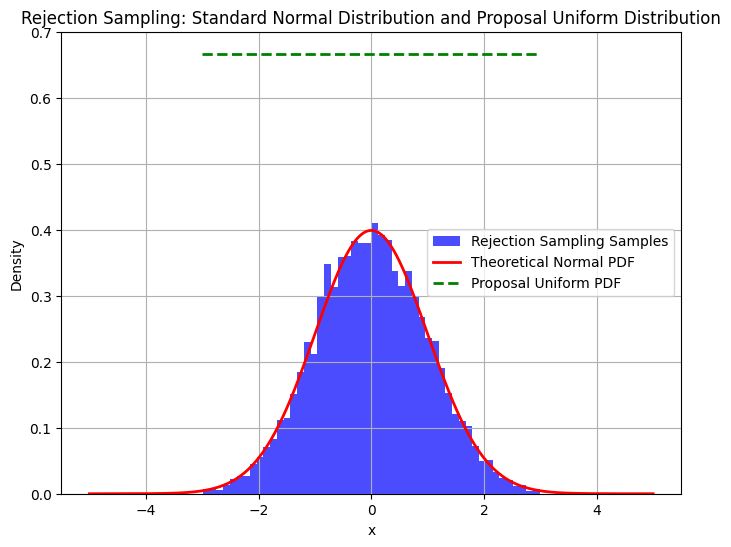

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 标准正态分布的目标PDF
def target_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

# 均匀分布的简单PDF
def proposal_pdf(x, b):
    return 1 / (2 * b) if abs(x) <= b else 0

# 拒绝采样实现
def rejection_sampling(target_pdf, proposal_pdf, M, b, n_samples):
    samples = []
    while len(samples) < n_samples:
        # 从简单分布g(x)采样
        x_star = np.random.uniform(-b, b)
        
        # 从均匀分布[0,1]中采样
        u = np.random.rand()
        
        # 拒绝采样的接受-拒绝条件
        if u * M * proposal_pdf(x_star, b) <= target_pdf(x_star):
            samples.append(x_star)
    return np.array(samples)

# 参数设置
b = 3               # 调整均匀分布的范围
M = 4  # 确保M满足f(x) <= M * g(x)
n_samples = 10000   # 生成的样本数

# 进行拒绝采样
samples = rejection_sampling(target_pdf, proposal_pdf, M, b, n_samples)

# 绘制生成的样本的直方图
plt.figure(figsize=(8, 6))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='blue', label='Rejection Sampling Samples')

# 绘制标准正态分布的PDF
x = np.linspace(-5, 5, 1000)
pdf = target_pdf(x)
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical Normal PDF')

# 绘制均匀分布（proposal_pdf）的PDF
proposal_x = np.linspace(-b, b, 1000)
proposal_pdf_vals = []
for xi in proposal_x:
    proposal_pdf_vals.append(M*proposal_pdf(xi, b))

plt.plot(proposal_x, proposal_pdf_vals, 'g--', lw=2, label='Proposal Uniform PDF')

# 设置图形
plt.title('Rejection Sampling: Standard Normal Distribution and Proposal Uniform Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

#### 提议分布为正态分布

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 目标PDF：标准正态分布
def target_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

# 高斯提议分布PDF（均值为0，标准差为proposal_std）
def proposal_pdf(x, proposal_std):
    return np.exp(-0.5 * (x / proposal_std)**2) / (proposal_std * np.sqrt(2 * np.pi))

# 拒绝采样实现
def rejection_sampling(target_pdf, proposal_pdf, M, proposal_std, n_samples):
    samples = []
    while len(samples) < n_samples:
        # 从高斯分布中采样
        x_star = np.random.normal(0, proposal_std)
        
        # 从均匀分布[0,1]中采样
        u = np.random.rand()
        
        # 拒绝采样的接受-拒绝条件
        if u * M * proposal_pdf(x_star, proposal_std) <= target_pdf(x_star):
            samples.append(x_star)
    return np.array(samples)

# 参数设置
proposal_std = 5  # 提议高斯分布的标准差
M = 11            # 根据最大 f(x)/g(x) 设置的上界（估计值）
n_samples = 10000

# 进行拒绝采样
samples = rejection_sampling(target_pdf, proposal_pdf, M, proposal_std, n_samples)

# 绘图
x = np.linspace(-5, 5, 1000)
target_vals = target_pdf(x)
proposal_vals = proposal_pdf(x, proposal_std)
scaled_proposal = M * proposal_vals

plt.figure(figsize=(8, 6))
plt.hist(samples, bins=50, density=True, alpha=0.6, label='Rejection Sampling Samples')
plt.plot(x, target_vals, 'r-', lw=2, label='Target PDF (Standard Normal)')
plt.plot(x, scaled_proposal, 'g--', lw=2, label='Scaled Proposal PDF (M × g(x))')
plt.title('Rejection Sampling using Gaussian Proposal')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


### 重要性采样（Importance Sampling）

重要性采样是一种蒙特卡洛方法，用于从复杂的分布中进行采样。它通过从一个简单的“提议”分布中采样，并对样本进行加权来估算复杂分布的期望值。这个方法特别适用于无法直接从目标分布中采样，但可以从一个容易采样的分布中采样的情形。

#### 重要性采样的基本步骤：

1. **选择一个提议分布（Proposal Distribution）**，记为 $q(x)$，它比目标分布 $p(x)$ 更容易采样。
   
2. **生成样本**：从提议分布 $q(x)$ 中生成样本 $x_i$。
   
3. **计算重要性权重**：根据目标分布 $p(x)$ 和提议分布 $q(x)$ 的比值来计算每个样本的权重：

   $$
   w(x_i) = \frac{p(x_i)}{q(x_i)}
   $$

4. **估算期望值**：通过加权平均来估算目标分布的期望值：

   $$
   \mathbb{E}[f(X)] = \frac{1}{N} \sum_{i=1}^{N} w(x_i) f(x_i)
   $$

   其中 $f(x)$ 是你希望计算期望值的函数，$x_i$ 是从提议分布 $q(x)$ 中采样的样本。

#### 计算期望值

1. 计算 $ \mathbb{E}[\sin(X)] $

我们需要计算目标函数 $ f(x) = \sin(x) $ 的期望值。假设目标分布是标准正态分布 $ N(0, 1) $，即 $ p(x) = \frac{1}{\sqrt{2 \pi}} e^{-x^2 / 2} $。

期望值的公式为：

$$
\mathbb{E}[\sin(X)] = \int_{-\infty}^{\infty} \sin(x) p(x) \, dx
$$

标准正态分布是对称的，而 $ \sin(x) $ 是一个奇函数。由于标准正态分布关于原点对称，而 $ \sin(x) $ 是奇函数（即 $ \sin(-x) = -\sin(x) $），因此期望值为零：

$$
\mathbb{E}[\sin(X)] = 0
$$

2. 计算 $ \mathbb{E}[\cos(X)] $

我们接下来计算 $ f(x) = \cos(x) $ 的期望值。同样，假设目标分布是标准正态分布 $ N(0, 1) $。

期望值的公式为：

$$
\mathbb{E}[\cos(X)] = \int_{-\infty}^{\infty} \cos(x) p(x) \, dx
$$

- $ \cos(x) $ 是偶函数（即 $ \cos(-x) = \cos(x) $）。
- 标准正态分布是对称的。

对于偶函数 $ \cos(x) $ 和标准正态分布，期望值的积分不为零，其值为：

$$
\mathbb{E}[\cos(X)] = e^{-1/2}
$$

因此，理论期望值是：

$$
\mathbb{E}[\cos(X)] \approx 0.6065
$$

总结：

- 对于 $ \sin(x) $ 和标准正态分布，理论期望值是 0。
- 对于 $ \cos(x) $ 和标准正态分布，理论期望值是 $ e^{-1/2} \approx 0.6065 $。


通过重要性采样估算的期望值：0.60853929350704


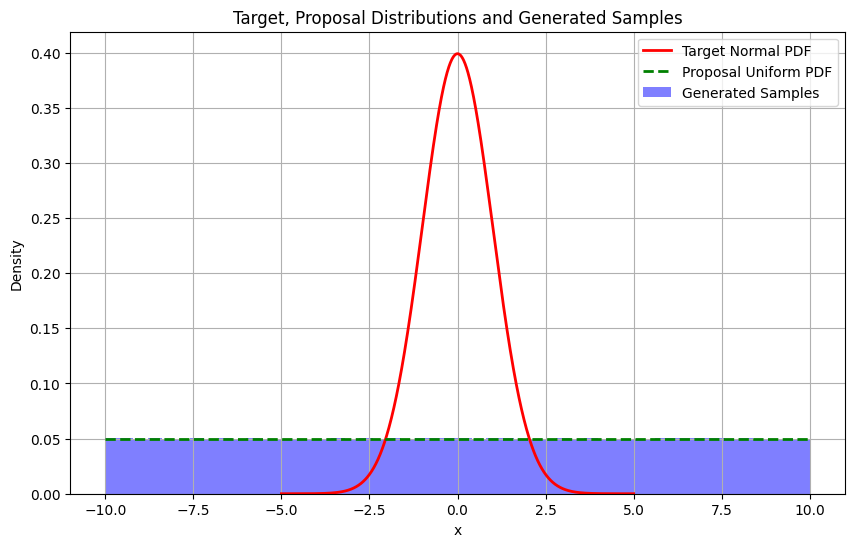

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 目标函数 f(x) = cos(x)
def target_function(x):
    return np.cos(x)

# 假设目标分布是标准正态分布 N(0, 1)
def target_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

# 提议分布是均匀分布 U(-b, b)
def proposal_pdf(x, b):
    return np.where(np.abs(x) <= b, 1 / (2 * b), 0)

# 重要性采样实现
def importance_sampling(target_pdf, proposal_pdf, b, n_samples, f):
    # 从提议分布中采样
    samples = np.random.uniform(-b, b, n_samples)
    
    # 计算每个样本的权重
    weights = target_pdf(samples) / proposal_pdf(samples, b)
    
    # 计算加权的期望值
    weighted_sum = np.sum(weights * f(samples))
    return weighted_sum / n_samples, samples

# 参数设置
b = 10             # 提议分布的范围
n_samples = 1000000  # 生成的样本数

# 使用重要性采样估算 sin(x) 的期望值
estimated_expectation, samples = importance_sampling(target_pdf, proposal_pdf, b, n_samples, target_function)
print(f"通过重要性采样估算的期望值：{estimated_expectation}")

# 绘制目标分布（标准正态分布）和提议分布（均匀分布）的图形
x = np.linspace(-5, 5, 1000)
target_pdf_vals = target_pdf(x)
proposal_x = np.linspace(-b, b, 1000)
proposal_pdf_vals = proposal_pdf(proposal_x, b)

plt.figure(figsize=(10, 6))

# 绘制目标分布（标准正态分布）
plt.plot(x, target_pdf_vals, 'r-', lw=2, label='Target Normal PDF')

# 绘制提议分布（均匀分布）
plt.plot(proposal_x, proposal_pdf_vals, 'g--', lw=2, label='Proposal Uniform PDF')

# 绘制生成的样本的直方图
plt.hist(samples, bins=50, density=True, alpha=0.5, label='Generated Samples', color='b')

plt.title('Target, Proposal Distributions and Generated Samples')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


### 采样方法 -- Box-Muller
计算机只能直接产生均匀分布随机数（或者说均匀分布是计算机用确定性算法能最直接、最廉价构造出来的分布），而正态分布的累积分布函数（CDF）没有初等闭式反函数，无法直接用逆变换采样。

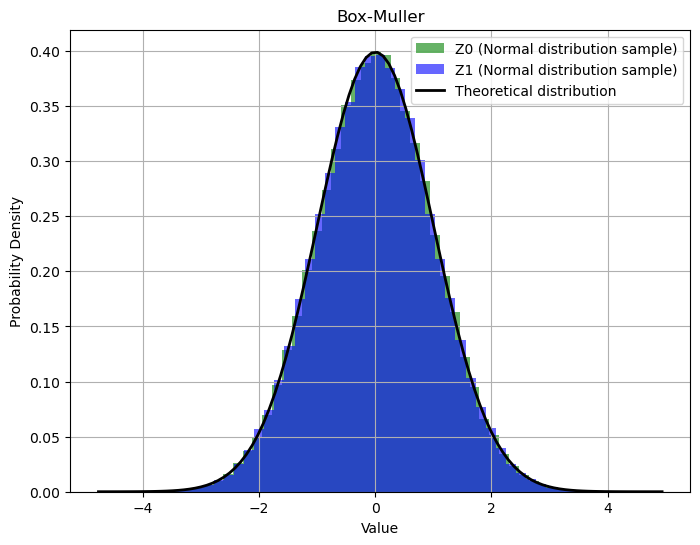

In [72]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Box-Muller transform function
def box_muller(num_samples):
    u1 = np.random.rand(num_samples)  # Uniform distribution random numbers u1
    u2 = np.random.rand(num_samples)  # Uniform distribution random numbers u2

    # Apply the Box-Muller transform to compute Z0 and Z1
    z0 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
    z1 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)

    return z0, z1

# Set the number of samples
num_samples = 100000

# Generate samples using the Box-Muller transform
z0, z1 = box_muller(num_samples)

# Plot the generated normal distribution samples
plt.figure(figsize=(8, 6))
plt.hist(z0, bins=50, density=True, alpha=0.6, color='g', label="Z0 (Normal distribution sample)")
plt.hist(z1, bins=50, density=True, alpha=0.6, color='b', label="Z1 (Normal distribution sample)")

# Plot the theoretical density function of the standard normal distribution

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x)
plt.plot(x, p, 'k', linewidth=2, label="Theoretical distribution")

# Add title and labels in English
plt.title("Box-Muller")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()
